# Diabetes — Exploratory Data Analysis
Dataset: Pima Indians Diabetes Database
Goal: understand the data before cleaning or modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline


## 1. Load the dataset

In [2]:
df = pd.read_csv("../../data/raw/diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Basic info
Shape, column types, and a quick statistical summary.

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. Check for missing / invalid values
In this dataset, missing data is often hidden as `0` in columns
where 0 is not medically possible (Glucose, BloodPressure,
SkinThickness, Insulin, BMI). We check for that here.

In [5]:
zero_not_allowed = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_not_allowed:
    count = (df[col] == 0).sum()
    print(f"{col}: {count} zero values ({count/len(df)*100:.1f}%)")


Glucose: 5 zero values (0.7%)
BloodPressure: 35 zero values (4.6%)
SkinThickness: 227 zero values (29.6%)
Insulin: 374 zero values (48.7%)
BMI: 11 zero values (1.4%)


## 4. Class balance
How many patients are diabetic (1) vs. not (0)?

Outcome
0    500
1    268
Name: count, dtype: int64


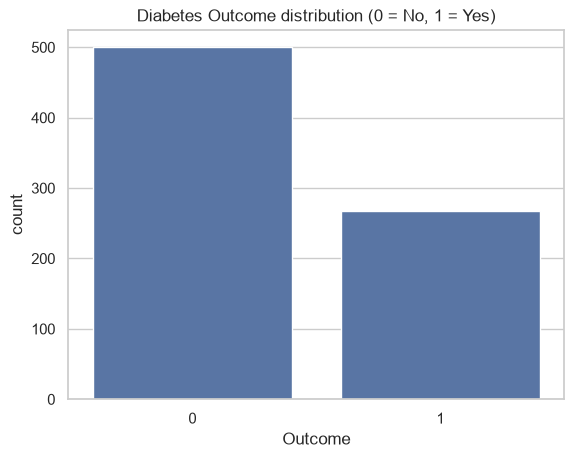

In [6]:
print(df["Outcome"].value_counts())

sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome distribution (0 = No, 1 = Yes)")
plt.show()


## 5. Feature distributions
Histogram for every numeric feature, to spot skew and outliers.

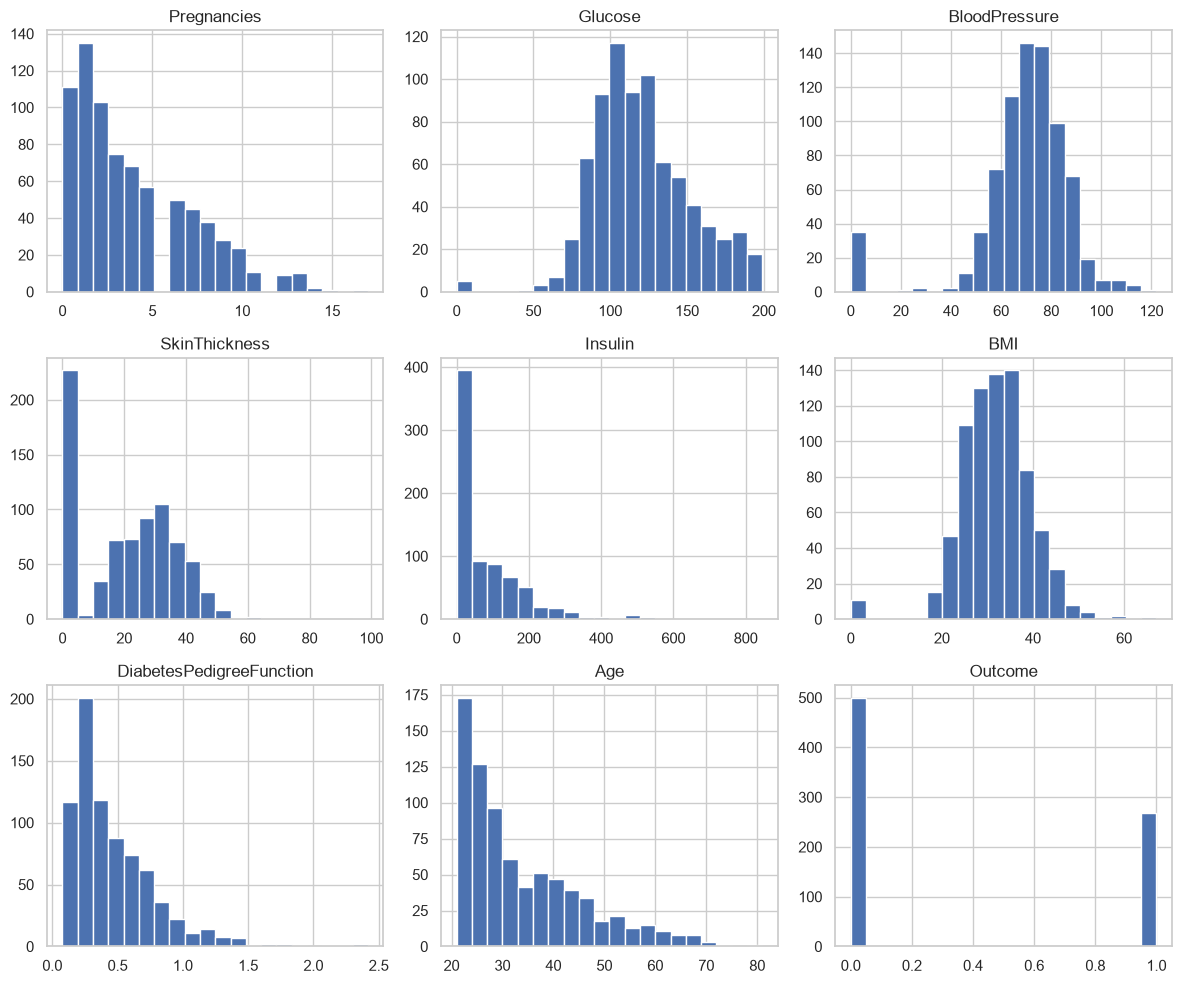

In [7]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()


## 6. Correlation heatmap
Which features move together, and which correlate most with Outcome?

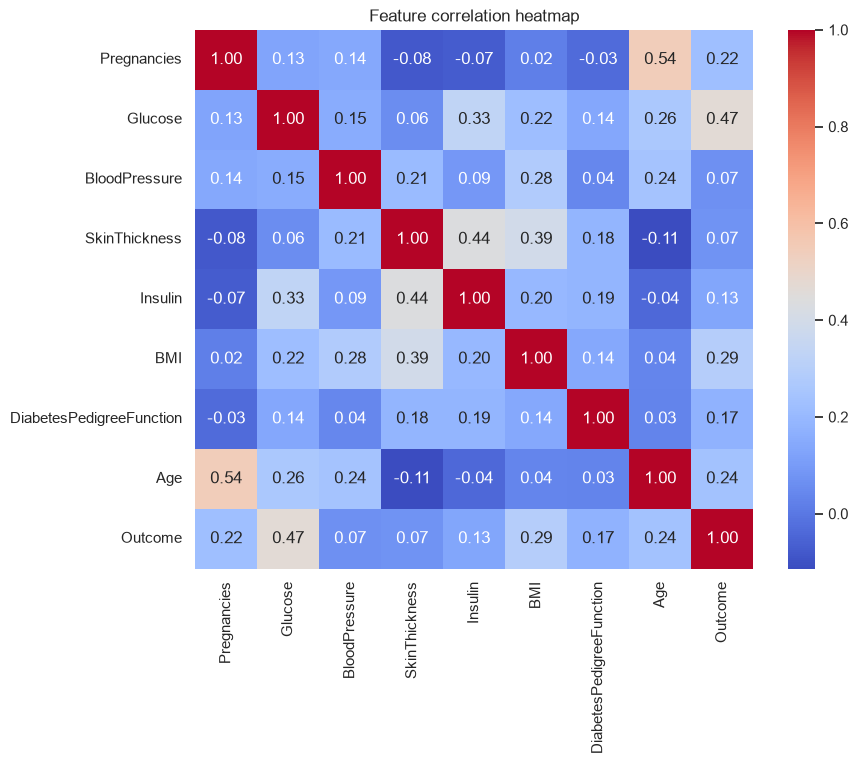

In [8]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation heatmap")
plt.show()


## 7. Boxplots by outcome
Do Glucose and BMI look different for diabetic vs non-diabetic patients?

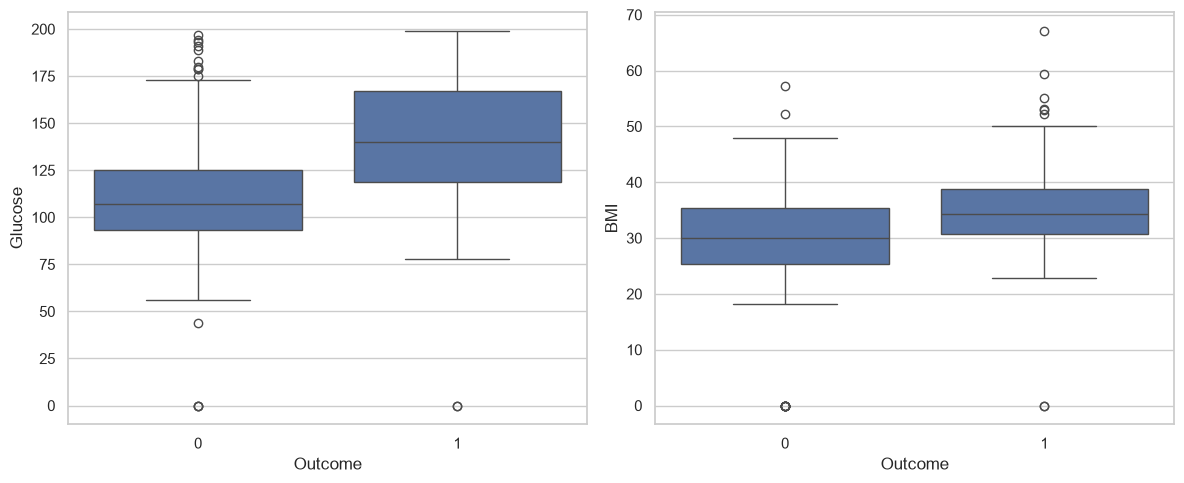

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="Outcome", y="Glucose", data=df, ax=axes[0])
sns.boxplot(x="Outcome", y="BMI", data=df, ax=axes[1])
plt.tight_layout()
plt.show()


## Notes / takeaways
_Write down what you notice here before moving to preprocessing:_
- Which columns had suspicious zero values?
- Is the class balance roughly even, or skewed?
- Which features look most correlated with Outcome?
